In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
LOCAL_DATA_DIR = PROJECT_ROOT / 'Final datasets'
CUBEMS_COMBINED_CSV = LOCAL_DATA_DIR / 'cubems-smart-building-energy-and-iaq-data.csv'
CUBEMS_RAW_DIR = PROJECT_ROOT / 'cubems-smart-building-energy-and-iaq-data'

print(f'Project root: {PROJECT_ROOT}')
print(f'Tracked data directory: {DATA_DIR}')
print(f'Local-only large dataset directory: {LOCAL_DATA_DIR}')

# Code for normalizing all the csv's in the CU-BEMS dataset into a single csv

In [ ]:
import pandas as pd
import os
import re

folder_path = CUBEMS_RAW_DIR

dfs = []

for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        file_path = os.path.join(folder_path, file)
        
        df = pd.read_csv(file_path)
        
        # Clean column names
        df.columns = df.columns.str.strip().str.lower()
        
        # Extract metadata
        match = re.match(r"(\d{4})Floor(\d+)", file)
        if not match:
            continue
        
        year = int(match.group(1))
        floor = int(match.group(2))
        
        # Add metadata
        df["year"] = year
        df["floor"] = floor
        
        # Robust timestamp handling (FIXED)
        if "date" in df.columns:
            df["date"] = pd.to_datetime(df["date"], errors='coerce')
            df = df.dropna(subset=["date"])
        elif "timestamp" in df.columns:
            df["timestamp"] = pd.to_datetime(df["timestamp"], errors='coerce')
            df = df.dropna(subset=["timestamp"])
        
        dfs.append(df)

# Combine all dataframes
final_df = pd.concat(dfs, ignore_index=True, sort=False)

# Handle missing values
final_df = final_df.fillna(0)

# Sorting
if "date" in final_df.columns:
    final_df = final_df.sort_values(by=["year", "floor", "date"])
elif "timestamp" in final_df.columns:
    final_df = final_df.sort_values(by=["year", "floor", "timestamp"])

# Reset index
final_df = final_df.reset_index(drop=True)

# Move important columns to front
priority_cols = ["year", "floor"]

if "date" in final_df.columns:
    priority_cols.append("date")
elif "timestamp" in final_df.columns:
    priority_cols.append("timestamp")

cols = priority_cols + [col for col in final_df.columns if col not in priority_cols]
final_df = final_df[cols]

# Save final dataset
output_path = LOCAL_DATA_DIR / "cubems-smart-building-energy-and-iaq-data.csv"
final_df.to_csv(output_path, index=False)

print("Done", final_df.shape)

In [3]:
cols = ['year', 'floor'] + [col for col in final_df.columns if col not in ['year', 'floor']]
final_df = final_df[cols]

In [ ]:
final_df.to_parquet(LOCAL_DATA_DIR / "cubems-smart-building-energy-and-iaq-data.parquet")

In [ ]:
if (LOCAL_DATA_DIR / "cubems-smart-building-energy-and-iaq-data.parquet").exists():
    df = pd.read_parquet(LOCAL_DATA_DIR / "cubems-smart-building-energy-and-iaq-data.parquet")
else:
    df = pd.read_csv(CUBEMS_COMBINED_CSV)

In [6]:
len(df)

5432488

In [7]:
df.head()

,year,floor,date,z1_light(kw),z1_plug(kw),z2_ac1(kw),z2_ac2(kw),z2_ac3(kw),z2_ac4(kw),z2_light(kw),...,z2_ac8(kw),z2_ac9(kw),z2_ac10(kw),z2_ac11(kw),z2_ac12(kw),z2_ac13(kw),z2_ac14(kw),z3_s1(degc),z3_s1(rh%),z3_s1(lux)
0,2018,1,2018-07-01 00:00:00,12.94,18.56,45.24,0.01,0.01,0.00,13.76,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2018,1,2018-07-01 00:01:00,12.97,18.55,45.28,0.02,0.01,0.01,13.76,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2018,1,2018-07-01 00:02:00,12.97,18.55,45.24,0.01,0.01,0.01,13.79,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2018,1,2018-07-01 00:03:00,12.98,18.58,45.26,0.02,0.01,0.00,13.81,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2018,1,2018-07-01 00:04:00,13.01,18.60,45.22,0.02,0.01,0.01,13.83,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
df['year'].value_counts()

year
2019    3577768
2018    1854720
Name: count, dtype: int64

In [9]:
df['year'].unique

<bound method Series.unique of 0          2018
1          2018
2          2018
3          2018
4          2018
           ... 
5432483    2019
5432484    2019
5432485    2019
5432486    2019
5432487    2019
Name: year, Length: 5432488, dtype: int64>

In [10]:
df.columns

Index(['year', 'floor', 'date', 'z1_light(kw)', 'z1_plug(kw)', 'z2_ac1(kw)',
       'z2_ac2(kw)', 'z2_ac3(kw)', 'z2_ac4(kw)', 'z2_light(kw)', 'z2_plug(kw)',
       'z3_light(kw)', 'z3_plug(kw)', 'z4_light(kw)', 'z1_ac1(kw)',
       'z1_ac2(kw)', 'z1_ac3(kw)', 'z1_ac4(kw)', 'z1_s1(degc)', 'z1_s1(rh%)',
       'z1_s1(lux)', 'z2_s1(degc)', 'z2_s1(rh%)', 'z2_s1(lux)', 'z4_ac1(kw)',
       'z4_plug(kw)', 'z4_s1(degc)', 'z4_s1(rh%)', 'z4_s1(lux)', 'z5_ac1(kw)',
       'z5_light(kw)', 'z5_plug(kw)', 'z5_s1(degc)', 'z5_s1(rh%)',
       'z5_s1(lux)', 'z4_ac2(kw)', 'z4_ac3(kw)', 'z4_ac4(kw)', 'z2_ac5(kw)',
       'z2_ac6(kw)', 'z2_ac7(kw)', 'z2_ac8(kw)', 'z2_ac9(kw)', 'z2_ac10(kw)',
       'z2_ac11(kw)', 'z2_ac12(kw)', 'z2_ac13(kw)', 'z2_ac14(kw)',
       'z3_s1(degc)', 'z3_s1(rh%)', 'z3_s1(lux)'],
      dtype='object')

In [11]:
df.isnull().sum()

year            0
floor           0
date            0
z1_light(kw)    0
z1_plug(kw)     0
z2_ac1(kw)      0
z2_ac2(kw)      0
z2_ac3(kw)      0
z2_ac4(kw)      0
z2_light(kw)    0
z2_plug(kw)     0
z3_light(kw)    0
z3_plug(kw)     0
z4_light(kw)    0
z1_ac1(kw)      0
z1_ac2(kw)      0
z1_ac3(kw)      0
z1_ac4(kw)      0
z1_s1(degc)     0
z1_s1(rh%)      0
z1_s1(lux)      0
z2_s1(degc)     0
z2_s1(rh%)      0
z2_s1(lux)      0
z4_ac1(kw)      0
z4_plug(kw)     0
z4_s1(degc)     0
z4_s1(rh%)      0
z4_s1(lux)      0
z5_ac1(kw)      0
z5_light(kw)    0
z5_plug(kw)     0
z5_s1(degc)     0
z5_s1(rh%)      0
z5_s1(lux)      0
z4_ac2(kw)      0
z4_ac3(kw)      0
z4_ac4(kw)      0
z2_ac5(kw)      0
z2_ac6(kw)      0
z2_ac7(kw)      0
z2_ac8(kw)      0
z2_ac9(kw)      0
z2_ac10(kw)     0
z2_ac11(kw)     0
z2_ac12(kw)     0
z2_ac13(kw)     0
z2_ac14(kw)     0
z3_s1(degc)     0
z3_s1(rh%)      0
z3_s1(lux)      0
dtype: int64

In [ ]:
df_gdcd = pd.read_csv(DATA_DIR / "global-data-center-dataset.csv")
df_gdcd.head(5)

In [13]:
df_gdcd[df_gdcd['country']=='India']

,country,total_data_centers,hyperscale_data_centers,colocation_data_centers,floor_space_sqft_total,power_capacity_MW_total,average_renewable_energy_usage_percent,tier_distribution,key_operators,cloud_provider,...,avg_latency_to_global_hubs_ms,number_of_fiber_connections,growth_rate_of_data_centers_percent_per_year,cooling_technologies_common,regulatory_challenges_or_limits,disaster_recovery_sites_common,green_dc_initiatives_description,source_of_data,Unnamed: 19,Unnamed: 20
13,India,99,10,~50,"~50,000,000",~400,0.15,"II:30%, III:60%, IV:10%","STT GDC, NTT, CtrlS, AWS","AWS:Yes, GCP:Yes, Azure:Yes, Oracle:Yes",...,100,15+,18%,"Air, Liquid","Power supply, land acquisition","Yes, for BFSI/IT","Solar, wind, green building codes","Brightlio, CBRE, IEA",NaN,NaN


In [14]:
numeric_like_cols = [
    "floor_space_sqft_total",
    "power_capacity_MW_total",
    "average_renewable_energy_usage_percent",
    "internet_penetration_percent",
    "avg_latency_to_global_hubs_ms",
    "number_of_fiber_connections",
    "growth_rate_of_data_centers_percent_per_year"
]

for col in numeric_like_cols:
    df_gdcd[col] = (
        df_gdcd[col]
        .astype(str)
        .str.replace(r"[><~%,+]", "", regex=True)
        .str.replace(r"[^0-9.\-]", "", regex=True)
        .replace({"": pd.NA, "nan": pd.NA})
    )
    df_gdcd[col] = pd.to_numeric(df_gdcd[col], errors="coerce")

In [15]:
import pandas as pd
import re

# Function to clean numeric-like strings
def clean_numeric(val):
    if isinstance(val, str):
        # Remove unwanted symbols
        val = re.sub(r"[><~%,+]", "", val)
        val = val.strip()
    return val

# Apply cleaning to all columns
df_gdcd = df_gdcd.applymap(clean_numeric)

# Convert all possible columns to numeric
for col in df_gdcd.columns:
    df_gdcd[col] = pd.to_numeric(df_gdcd[col], errors='ignore')

for col in df_gdcd.select_dtypes(include='object').columns:
    
    # Clean values
    df_gdcd[col] = df_gdcd[col].apply(clean_numeric)
    
    # Try converting to numeric
    try:
        df_gdcd[col] = df_gdcd[col].astype("double")
    except:
        pass  # keep as object if not convertible

print("Cleaning complete")
print(df_gdcd.dtypes)

Cleaning complete
country                                          object
total_data_centers                                int64
hyperscale_data_centers                           int64
colocation_data_centers                           int64
floor_space_sqft_total                          float64
power_capacity_MW_total                         float64
average_renewable_energy_usage_percent          float64
tier_distribution                                object
key_operators                                    object
cloud_provider                                   object
internet_penetration_percent                    float64
avg_latency_to_global_hubs_ms                   float64
number_of_fiber_connections                     float64
growth_rate_of_data_centers_percent_per_year    float64
cooling_technologies_common                      object
regulatory_challenges_or_limits                  object
disaster_recovery_sites_common                   object
green_dc_initiatives_descripti

/tmp/ipykernel_57/2225577510.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_gdcd = df_gdcd.applymap(clean_numeric)
/tmp/ipykernel_57/2225577510.py:17: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_gdcd[col] = pd.to_numeric(df_gdcd[col], errors='ignore')


In [16]:
df.head()

,year,floor,date,z1_light(kw),z1_plug(kw),z2_ac1(kw),z2_ac2(kw),z2_ac3(kw),z2_ac4(kw),z2_light(kw),...,z2_ac8(kw),z2_ac9(kw),z2_ac10(kw),z2_ac11(kw),z2_ac12(kw),z2_ac13(kw),z2_ac14(kw),z3_s1(degc),z3_s1(rh%),z3_s1(lux)
0,2018,1,2018-07-01 00:00:00,12.94,18.56,45.24,0.01,0.01,0.00,13.76,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2018,1,2018-07-01 00:01:00,12.97,18.55,45.28,0.02,0.01,0.01,13.76,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2018,1,2018-07-01 00:02:00,12.97,18.55,45.24,0.01,0.01,0.01,13.79,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2018,1,2018-07-01 00:03:00,12.98,18.58,45.26,0.02,0.01,0.00,13.81,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2018,1,2018-07-01 00:04:00,13.01,18.60,45.22,0.02,0.01,0.01,13.83,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
import matplotlib.pyplot as plt
import seaborn as sc

In [18]:
df_gdcd.columns

Index(['country', 'total_data_centers', 'hyperscale_data_centers',
       'colocation_data_centers', 'floor_space_sqft_total',
       'power_capacity_MW_total', 'average_renewable_energy_usage_percent',
       'tier_distribution', 'key_operators', 'cloud_provider',
       'internet_penetration_percent', 'avg_latency_to_global_hubs_ms',
       'number_of_fiber_connections',
       'growth_rate_of_data_centers_percent_per_year',
       'cooling_technologies_common', 'regulatory_challenges_or_limits',
       'disaster_recovery_sites_common', 'green_dc_initiatives_description',
       'source_of_data', 'Unnamed: 19', 'Unnamed: 20'],
      dtype='object')

In [19]:
df_gdcd.isnull().sum()

country                                           0
total_data_centers                                0
hyperscale_data_centers                           0
colocation_data_centers                           0
floor_space_sqft_total                          168
power_capacity_MW_total                          51
average_renewable_energy_usage_percent           51
tier_distribution                                12
key_operators                                    21
cloud_provider                                   42
internet_penetration_percent                    102
avg_latency_to_global_hubs_ms                    51
number_of_fiber_connections                     113
growth_rate_of_data_centers_percent_per_year    191
cooling_technologies_common                       1
regulatory_challenges_or_limits                   0
disaster_recovery_sites_common                   13
green_dc_initiatives_description                 26
source_of_data                                    4
Unnamed: 19 

In [20]:
len(df_gdcd)

191

In [21]:
# df_gdcd['hyperscale_data_centers'] = df_gdcd['hyperscale_data_centers'].astype(str).str.replace(r'\D+', '', regex=True)              #to convert the string 300+ and so on into only a numbered string
# df_gdcd['hyperscale_data_centers'] = df_gdcd['hyperscale_data_centers'].astype(int)   # to convert the string dataype column into integer

In [ ]:
df_gdcd.to_csv(DATA_DIR / "global-data-center-dataset.csv", index=False)

<Axes: xlabel='country'>

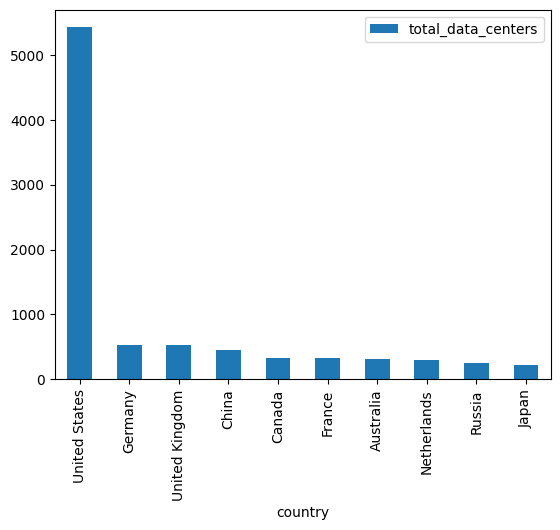

In [23]:
df_sort=df_gdcd.sort_values('total_data_centers', ascending=False).iloc[:10]
df_sort.plot.bar(x='country', y='total_data_centers')

<Axes: xlabel='country'>

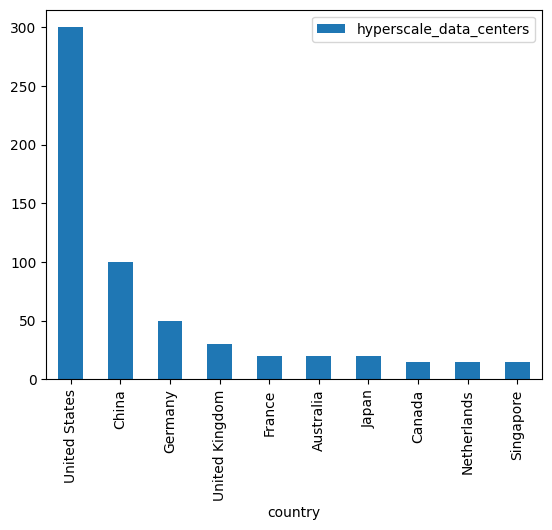

In [24]:
df_sort=df_gdcd.sort_values('hyperscale_data_centers', ascending=False).iloc[:10]
df_sort.plot.bar(x='country', y='hyperscale_data_centers')

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets

numeric_cols = df_gdcd.select_dtypes(include=['int64', 'float64']).columns

def update_plot(metric, top_n):
    
    filtered = df_gdcd.sort_values(metric, ascending=False).head(top_n)

    plt.figure(figsize=(12, 6))
    
    plt.bar(filtered['country'], filtered[metric])
    
    plt.title(f'Top {top_n} Countries by {metric}', fontsize=14)
    plt.xlabel('Country')
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.show()


metric_dropdown = widgets.Dropdown(
    options=numeric_cols,
    description='Metric:'
)

topn_slider = widgets.IntSlider(
    value=10,
    min=5,
    max=30,
    step=5,
    description='Top N:'
)

interact(update_plot, metric=metric_dropdown, top_n=topn_slider);

interactive(children=(Dropdown(description='Metric:', options=('total_data_centers', 'hyperscale_data_centers'…

In [32]:
def update_plot(metric, top_n):
    
    # Sort and take top N countries
    filtered = df_gdcd.sort_values(metric, ascending=False).head(top_n)

    plt.figure(figsize=(12, 6))
    
    plt.bar(filtered['country'], filtered[metric])
    
    plt.title(f'Top {top_n} Countries by {metric}', fontsize=14)
    plt.xlabel('Country')
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.show()


metric_dropdown = widgets.Dropdown(
    options=numeric_cols,
    description='Metric:'
)

topn_slider = widgets.IntSlider(
    value=10,
    min=5,
    max=30,
    step=5,
    description='Top N:'
)

interact(update_plot, metric=metric_dropdown, top_n=topn_slider);

interactive(children=(Dropdown(description='Metric:', options=('total_data_centers', 'hyperscale_data_centers'…

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(DATA_DIR / "state-ground-water-level-information.csv")


In [27]:
df

,State,Total Number of Monitored Stations,Observed Range of Water Level-min,Observed Range of Water Level-max
0,Andhra Pradesh,280,-98.46,203.54
1,Arunachal Pradesh,4,-4.19,-0.52
2,Assam,68,-89.66,30.73
3,Bihar,22,-20.98,1806.51
4,Chandigarh,19,-95.15,73.46
5,Chhattisgarh,243,-940.98,35.03
6,Delhi,89,-1000.00,44.25
7,Goa,39,-29.26,3.23
8,Gujarat,407,-231.45,25423.53
9,Haryana,207,-1000.00,100.12


In [28]:

df.columns = df.columns.str.strip()

min_col = [c for c in df.columns if "min" in c.lower()][0]
max_col = [c for c in df.columns if "max" in c.lower()][0]


df[min_col] = pd.to_numeric(df[min_col], errors='coerce')
df[max_col] = pd.to_numeric(df[max_col], errors='coerce')

threshold = 400  

outliers = df[df[max_col] > threshold]

print("Outliers detected:")
print(outliers[[min_col, max_col]])


df.loc[df[max_col] > threshold, max_col] = np.nan


df.loc[df[max_col] < df[min_col], max_col] = np.nan


print("\nCleaned data types:")
print(df.dtypes)

print("\nSummary stats:")
print(df[[min_col, max_col]].describe())


print("\nCleaning complete. File saved.")

Outliers detected:
    Observed Range of Water Level-min  Observed Range of Water Level-max
3                              -20.98                            1806.51
8                             -231.45                           25423.53
13                            -150.02                          295445.63
15                            -176.55                          992101.44
16                            -107.23                            4272.91
19                             -39.76                           33591.91
21                            -857.16                             971.40
23                            -906.60                             965.80

Cleaned data types:
State                                  object
Total Number of Monitored Stations      int64
Observed Range of Water Level-min     float64
Observed Range of Water Level-max     float64
dtype: object

Summary stats:
       Observed Range of Water Level-min  Observed Range of Water Level-max
count        

In [29]:
df

,State,Total Number of Monitored Stations,Observed Range of Water Level-min,Observed Range of Water Level-max
0,Andhra Pradesh,280,-98.46,203.54
1,Arunachal Pradesh,4,-4.19,-0.52
2,Assam,68,-89.66,30.73
3,Bihar,22,-20.98,NaN
4,Chandigarh,19,-95.15,73.46
5,Chhattisgarh,243,-940.98,35.03
6,Delhi,89,-1000.00,44.25
7,Goa,39,-29.26,3.23
8,Gujarat,407,-231.45,NaN
9,Haryana,207,-1000.00,100.12


In [ ]:
df = pd.read_csv(DATA_DIR / "area-wise-waterbodies-count-of-india.csv")

In [31]:
df

,State,< 0.5 ha,>= 0.5 - < 1 ha,>= 1 - < 2 ha,>= 2 - < 10 ha,>= 10 - < 50 ha,>= 50 - < 100 ha,>= 100 ha
0,Andaman & Nicobar,9,1,2,9,4,6,2
1,Andhra Pradesh,3342,5265,7203,14535,5057,783,548
2,Arunachal Pradesh,187,150,222,488,214,13,1
3,Assam,8796,2209,1416,1574,539,63,39
4,Bihar,36455,13572,6268,3964,929,110,72
5,Chhattisgarh,50490,25155,17755,9669,1183,102,93
6,Chandigarh,0,0,0,0,0,0,1
7,Daman & Diu,3,1,3,19,3,0,0
8,Delhi,11,13,14,13,2,0,0
9,Dadara & Nagar Havelli,0,1,0,2,0,0,1
